# Seaborn: Statistical Visualization

In [1]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

## 1. Introduction

### 1.1. Motivation
The [Anscombe's quartet] comprises 4 datasets that have nearly identical simple descriptive statistics, however they appear very differently when plotted. These statistics are:
- Number of observations of $\mathbf{x}$ and $\mathbf{y}$
- Mean of $\mathbf{x}$ and $\mathbf{y}$ ($\mu$)
- Variance of $\mathbf{x}$ and $\mathbf{y}$ ($\sigma^2$)
- Correlation coefficient between $\mathbf{x}$ and $\mathbf{y}$ ($\rho_{\mathbf{x},\mathbf{y}}$)
- Linear regression equation
- Coefficient of determinant ($R^2$)

[Anscombe's quartet]: https://en.wikipedia.org/wiki/Anscombe%27s_quartet

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

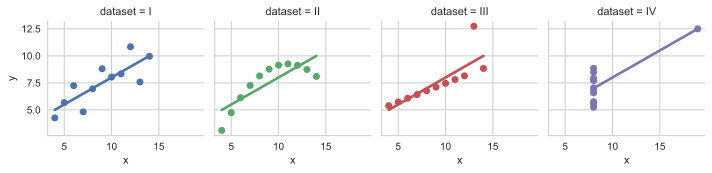

In [8]:
df_anscombe = sns.load_dataset('anscombe')

# fig, ax = plt.subplots(figsize=(10, 6))
sns.lmplot(
    data=df_anscombe,
    x='x', y='y',
    col='dataset', hue='dataset',
    ci=False, height=2.5,
    scatter_kws={'s': 50, 'alpha': 1},
)
plt.show()

### 1.2. Colors

#### Built-in colors
Some nice colors by CSS name are: `dimgrey` `indianred` `tomato` `goldenrod` `seagreen` `teal` `darkturquoise` `darkslategrey` `slategrey` `royalblue` `rebeccapurple`.

:::{image} ../image/chap_05/matplotlib_color_names.svg
:height: 700px
:align: center
:::

#### More colors

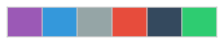

In [102]:
colors = ["#9B59B6", "#3498DB", "#95A5A6", "#E74C3C", "#34495E", "#2ECC71"]
sns.palplot(sns.color_palette(colors), size=0.5)

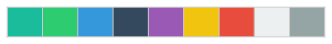

In [103]:
colors = ["#1ABC9C", "#2ECC71", "#3498DB", "#34495E", "#9B59B6", "#F1C40F", "#E74C3C", "#ECF0F1", "#95A5A6"]
sns.palplot(sns.color_palette(colors), size=0.5)

### 1.3. Scales of measurement
Measurement |Type        |Order    |Subtract |Divide   |Example|
:-----------|:-----------|:-------:|:-------:|:-------:|:----|
**Nominal** |Qualitative |         |         |         |Fruits, Gender, Names|
**Ordinal** |Qualitative |&check;  |         |         |Medals, Satisfaction, Age ranges|
**Interval**|Quantitative|&check;  |&check;  |         |Date, Temperature, Scores|
**Ratio**   |Quantitative|&check;  |&check;  |&check;  |Weight, Height, Time period|

More explanation for [scales of measurement]:
- Ratio is characterized by an absolute zero, which represents the absence of the property being measured. For example: the amount of money can be $0.
- Interval can be subtracted, but you cannot do division on it. For example: 6h00, 12h00 and 18h00 are equally spaced; but saying 12h00 is twice as much as 6h00 doesn't make sense.
- Ordinal can be numbers, for example: to measure satisfaction, you are asked to rate from 1 (very disappointed) from 5 (very pleasant).

In Data Visualization, the three popular data types are *Categorical* (nominal and ordinal), *Date/Time* (interval) and *Value* (ratio).

[scales of measurement]: https://en.wikipedia.org/wiki/Level_of_measurement

## 2. Basic charts
Basic charts are simple and easy-to-read, and are very good at reporting. In this section, we focus on analyzing how many dimensions a chart can display.

### 2.1. Pie chart
[Pie charts](https://en.wikipedia.org/wiki/Pie_chart) show the percentage represented by each category. This type of chart is rarely used in analytics; however, it can vary chart shapes in your reports/dashboards. Pie charts can display 2 dimensions:
- *arc angle*: a numeric variable
- *color*: a categorical variable

In [1]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [47]:
df_world = (
    pd.read_csv('../data/gapminder.csv')
    .query("continent != 'Oceania'")
)
df_world.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [48]:
def pie_chart(data, x, y, agg=np.sum, figsize=(4,4)):    
    data = data.groupby(x)[y].agg(agg).reset_index()
    fig, ax = plt.subplots(figsize=figsize)
    plt.pie(data[y], labels=data[x], autopct='{:.2f}%'.format)
    plt.show()

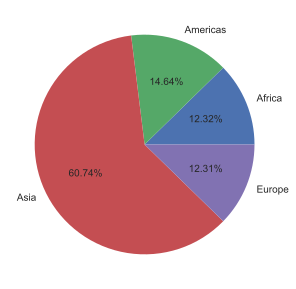

In [49]:
pie_chart(df_world, x='continent', y='pop')

### 2.2. Line chart
[Line charts] are always used for time series data thanks to the ability of emphasizing fluctuations and trends. The Seaborn's implementation [`sns.lineplot()`] can display 3 dimensions:
- $x$-*axis*: a datetime variable
- $y$-*axis*: a numeric variable
- *color*: a categorical variable

[Line charts]: https://en.wikipedia.org/wiki/Line_chart
[`sns.lineplot()`]: https://seaborn.pydata.org/generated/seaborn.lineplot.html

In [50]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [51]:
df_temp = (
    pd.read_csv('../data/temperatures.csv')
    .astype({'date': 'datetime64[ns]'})
    .sort_values(['city', 'date'])
    .assign(smooth_temp = lambda df: df.groupby('city')['temperature'].rolling(window=7, center=True).mean().values)
)
df_temp.head()

,date,city,temperature,smooth_temp
2,2011-10-01,Austin,72.2,NaN
5,2011-10-02,Austin,67.7,NaN
8,2011-10-03,Austin,69.4,NaN
11,2011-10-04,Austin,68.0,72.714286
14,2011-10-05,Austin,72.4,73.671429


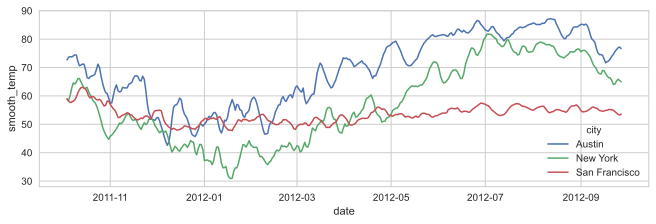

In [52]:
fig, ax = plt.subplots(figsize=(9,3))
sns.lineplot(data=df_temp, x='date', y='smooth_temp', hue='city', estimator=np.median, linewidth=1.5, ax=ax)
plt.show()

### 2.3. Bar chart
[Bar charts] have three variants: grouped, stacked and percent. They are very helpful in comparison, which requires the $y$-axis to start from 0. The Seaborn's implementation [`sns.barplot()`] can display 3 dimensions:
- $x$-*axis*: a categorical or date variable
- $y$-*axis*: a numeric variable
- *color*: a categorical variable

[Bar charts]: https://en.wikipedia.org/wiki/Bar_chart
[`sns.barplot()`]: https://seaborn.pydata.org/generated/seaborn.barplot.html

In [53]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [54]:
columns = ['invoice_id', 'product_line', 'profit', 'payment']
df_sales = pd.read_csv('../data/supermarket_sales.csv', usecols=columns)
df_sales.head()

,invoice_id,product_line,payment,profit
0,750-67-8428,Health and beauty,Ewallet,26.1415
1,226-31-3081,Electronic accessories,Cash,3.8200
2,631-41-3108,Home and lifestyle,Credit card,16.2155
3,123-19-1176,Health and beauty,Ewallet,23.2880
4,373-73-7910,Sports and travel,Ewallet,30.2085


In [55]:
def bar_chart(data, x, y, c, agg=np.sum, mode='group', orient='vertical', figsize=None):
    if mode == 'group':
        if orient.startswith('v'):
            fig, ax = plt.subplots(figsize=figsize)
            sns.barplot(data=data, x=x, y=y, hue=c, estimator=agg, ci=False, ax=ax)

        if orient.startswith('h'):
            fig, ax = plt.subplots(figsize=figsize)
            sns.barplot(data=data, x=y, y=x, hue=c, estimator=agg, ci=False, orient='h')
        
    if mode == 'stack':
        data = data.pivot_table(index=x, columns=c, values=y, aggfunc=agg)
        if orient.startswith('v'):
            data.plot.bar(stacked=True, figsize=figsize)
            plt.legend(bbox_to_anchor=(1.04,1), loc='upper left')

        if orient.startswith('h'):
            data.plot.barh(stacked=True, figsize=figsize)
            plt.legend(bbox_to_anchor=(1.04,1), loc='upper left')
            
    if mode == 'percent':
        data = data.pivot_table(index=x, columns=c, values=y, aggfunc=agg)
        data = data.div(data.sum(1), axis=0)
        if orient.startswith('v'):
            data.plot.bar(stacked=True, figsize=figsize)
            plt.legend(bbox_to_anchor=(1.04,1), loc='upper left')

        if orient.startswith('h'):
            data.plot.barh(stacked=True, figsize=figsize)
            plt.legend(bbox_to_anchor=(1.04,1), loc='upper left')
    
    plt.show()

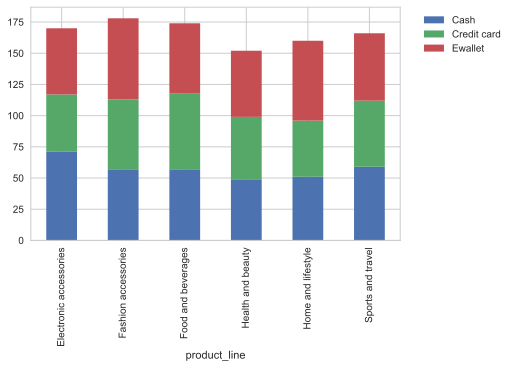

In [ ]:
bar_chart(data=df_sales, x='product_line', y='profit', c='payment', mode='stack', orient='v', agg=np.size, figsize=(7,5))

### 2.4. Area chart
[Area charts](https://en.wikipedia.org/wiki/Area_chart) are similar to stacked bar charts. Area charts can display 3 dimensions:
- $x$-*axis*: a categorical variable
- $y$-*axis*: a numeric variable
- *color*: a categorical variable

In [29]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [24]:
df_world = (
    pd.read_csv('../data/gapminder.csv')
    .query("continent != 'Ocenia'")
    .eval("gdp = pop * gdpPercap")
)
df_world.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num,gdp
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4,6.567086e+09
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4,7.585449e+09
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4,8.758856e+09
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4,9.648014e+09
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4,9.678553e+09


In [32]:
def area_chart(data, x, y, c, agg=np.sum, mode='stack', figsize=None):
    data = data.pivot_table(index=x, columns=c, values=y, aggfunc=agg)
    if mode == 'stack':
        data.plot.area(stacked=True, figsize=figsize)
        plt.legend(bbox_to_anchor=(1.04,1), loc='upper left', title=c)
        plt.ylabel(y)
        
    if mode == 'percent':
        data = data.div(data.sum(axis=1), axis=0)
        data.plot.area(stacked=True, figsize=figsize)
        plt.legend(bbox_to_anchor=(1.04,1), loc='upper left', title=c)
        plt.ylabel(y)

    plt.show()

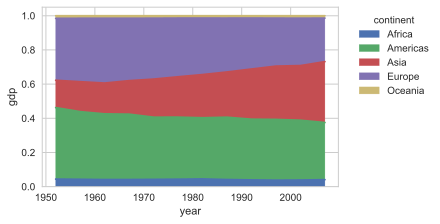

In [34]:
area_chart(data=df_world, x='year', y='gdp', c='continent', mode='percent', figsize=(6,3))

### 2.5. Scatter plot
[Scatter plots] are used to visualize the distribution and relationship of two variables. The Seaborn's function [`sns.scatterplot()`] can display 4 variables:
- $x$-*axis*: a categorical or numeric variable
- $y$-*axis*: a categorical or numeric variable
- *color*: a categorical variable
- *size*: a categorical or numeric variable

Sometimes, letting both color and size represent a single variable is better since differences are emphasized. If a categorical variable is assigned to one of the two axes, a variant of scatter plot called swarm plot may be the better choice.

[Scatter plots]: https://en.wikipedia.org/wiki/Scatter_plot
[`sns.scatterplot()`]: https://seaborn.pydata.org/generated/seaborn.scatterplot.html

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [37]:
columns = ['price', 'horsepower', 'engine_size']
df_car = pd.read_csv('../data/cars/tiny.csv', usecols=columns)
df_car.head()

,price,engine_size,horsepower
0,13.4,2.2,110
1,11.4,2.2,110
2,15.1,3.4,160
3,15.9,2.2,110
4,16.3,3.8,170


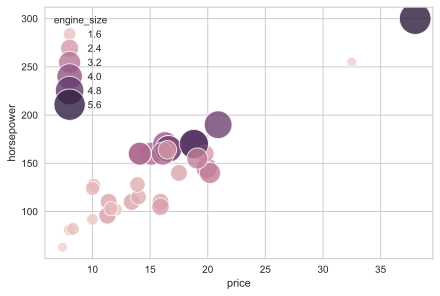

In [43]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(
    data=df_car,
    x='price', y='horsepower', hue='engine_size', size='engine_size',
    s=100, alpha=0.8,
    sizes=(100,1000),
    ax=ax,
)
plt.show()

#### Swarm plot
[`sns.swarmplot()`] is the non-overlap version of scatter plot. When either $x$-axis or $y$-axis is a categorical variable or when the dataset is very large, swarm plot may be more useful than original scatter plot.

[`sns.swarmplot()`]: https://seaborn.pydata.org/generated/seaborn.swarmplot.html

In [93]:
df_iris = sns.load_dataset('iris')
df_iris = pd.melt(df_iris, 'species', var_name='measurement')
df_iris.head()

,species,measurement,value
0,setosa,sepal_length,5.1
1,setosa,sepal_length,4.9
2,setosa,sepal_length,4.7
3,setosa,sepal_length,4.6
4,setosa,sepal_length,5.0


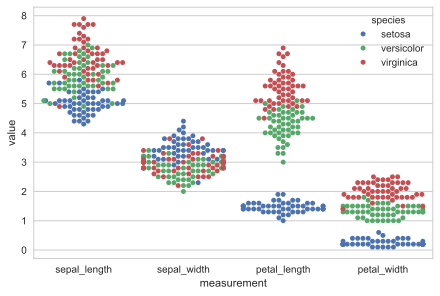

In [94]:
plt.figure(figsize=(6,4))
sns.swarmplot(data=df_iris, x='measurement', y='value', hue='species')
plt.show()

## 3. Statistical charts
Statistical charts do not focus on the number of dimensions, but they give Data Scientists a very deep understanding of the data. Statistical charts require good analytical skills to read, and are widely used in data analytics.

### 3.1. Heat map
[Heat maps] highlight values (large or small, negative or positive). Although heat maps are very simple, they usually go with a statistical table such as *correlation matrix* or *pivot table* and become very powerful in summarizing data. Depend on the value range, either a *sequential palette* or a *diverging palette* may be suitable. Implemented in Seaborn via [`sns.heatmap()`].

[Heat maps]: https://en.wikipedia.org/wiki/Heat_map
[`sns.heatmap()`]: https://seaborn.pydata.org/generated/seaborn.heatmap.html

In [17]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [20]:
df_car = pd.read_csv('../data/cars/tiny.csv')
df_car.head()

,manufacturer,model,type,min_price,price,max_price,mpg_city,mpg_highway,airbags,drive_train,...,passengers,length,wheelbase,width,turn_circle,rear_seat_room,luggage_room,weight,origin,make
0,Chevrolet,Cavalier,Compact,8.5,13.4,18.3,25,36,NaN,Front,...,5,182,101,66,38,25.0,13.0,2490,USA,Chevrolet Cavalier
1,Chevrolet,Corsica,Compact,11.4,11.4,11.4,25,34,Driver only,Front,...,5,184,103,68,39,26.0,14.0,2785,USA,Chevrolet Corsica
2,Chevrolet,Camaro,Sporty,13.4,15.1,16.8,19,28,Driver & Passenger,Rear,...,4,193,101,74,43,25.0,13.0,3240,USA,Chevrolet Camaro
3,Chevrolet,Lumina,Midsize,13.4,15.9,18.4,21,29,NaN,Front,...,6,198,108,71,40,28.5,16.0,3195,USA,Chevrolet Lumina
4,Chevrolet,Lumina_APV,Van,14.7,16.3,18.0,18,23,NaN,Front,...,7,178,110,74,44,30.5,NaN,3715,USA,Chevrolet Lumina_APV


#### Correlation matrix
The correlation coefficient of each variable pair is:

$$
\rho_{\mathbf{x},\mathbf{y}} =
\frac{1}{N} \sum_{n=1}^{N}{\frac{(x_n-\mu_{\mathbf{x}})(y_n-\mu_{\mathbf{y}})}{\sigma_{\mathbf{x}}\sigma_{\mathbf{y}}}}
$$

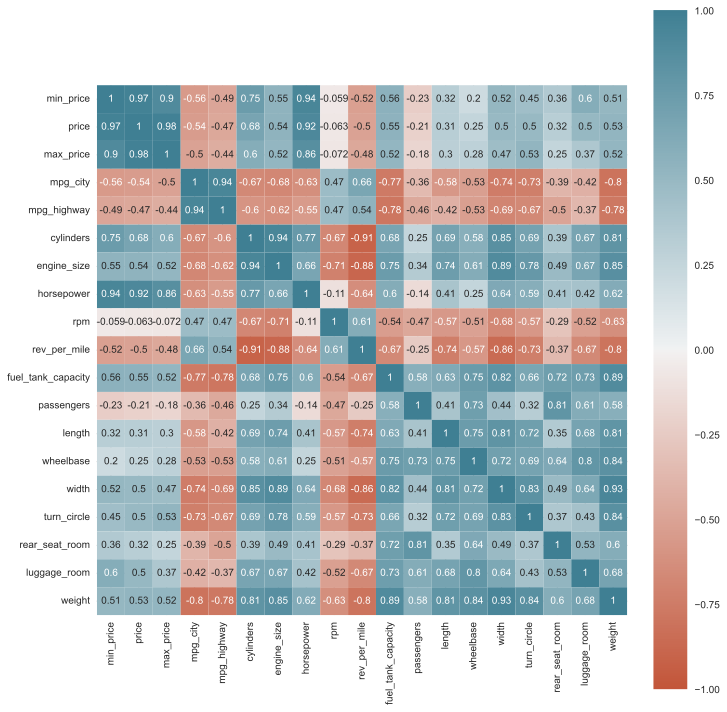

In [91]:
palette = sns.diverging_palette(20, 220, as_cmap=True)

plt.figure(figsize=(10,10))
sns.heatmap(
    df_car.select_dtypes([float, int]).corr(),
    square=True, annot=True,
    cmap=palette,
    vmin=-1, vmax=1,
)
plt.show()

# linecolor='white'
# linewidth=0.1

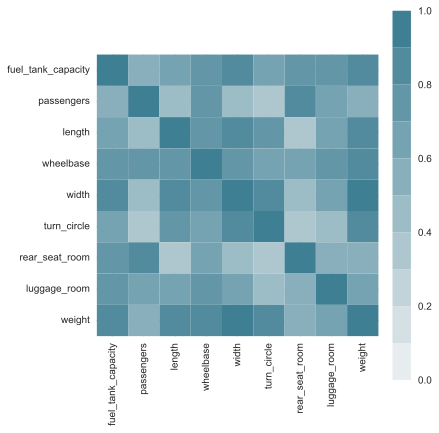

In [90]:
subset = [
    'fuel_tank_capacity', 'passengers', 'length', 'wheelbase', 'width',
    'turn_circle', 'rear_seat_room', 'luggage_room', 'weight'
]

palette = sns.diverging_palette(20, 220, n=20)[10:]

plt.figure(figsize=(6,6))
sns.heatmap(
    df_car[subset].corr(), square=True,
    cmap=palette,
    vmin=0, vmax=1,
)
plt.show()

#### Data summarizing

In [8]:
columns = ['manufacturer', 'max_price', 'price', 'min_price']
df_car = pd.read_csv('../data/cars.csv', usecols=columns)
df_car.head()

,manufacturer,min_price,price,max_price
0,Chevrolet,8.5,13.4,18.3
1,Chevrolet,11.4,11.4,11.4
2,Chevrolet,13.4,15.1,16.8
3,Chevrolet,13.4,15.9,18.4
4,Chevrolet,14.7,16.3,18.0


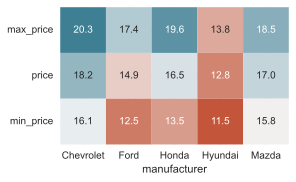

In [89]:
data = df_car.groupby('manufacturer')[['max_price', 'price', 'min_price']].mean().T
palette = sns.diverging_palette(20, 220, as_cmap=True)

plt.figure(figsize=(4,4))
g = sns.heatmap(
    data, square=True, annot=True,
    cmap=palette, cbar=False, fmt='.1f'
)
g.set_yticklabels(g.get_yticklabels(), rotation = 0)
plt.show()

### 3.2. Histogram
A [histogram] represents the distribution of a numerical variable. It counts how many observations fall into each bin (which is a range of values) and displays each bin as a bar. Notice that histograms look similar to bar charts, but they deliver completely different information.

[histogram]: https://en.wikipedia.org/wiki/Histogram

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [36]:
df_youtube = pd.read_csv('../data/youtube_trending.csv')
df_youtube = df_youtube.assign(year=df_youtube['trending_date'].astype('datetime64[ns]').dt.year.astype(str))
df_youtube.head(3)

,video_id,trending_date,channel_title,category_id,publish_time,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,year
0,2kyS6SvSYSE,2017-11-14,CaseyNeistat,22,2017-11-13T17:13:01.000Z,748374,57527,2966,15954,False,False,2017
1,1ZAPwfrtAFY,2017-11-14,LastWeekTonight,24,2017-11-13T07:30:00.000Z,2418783,97185,6146,12703,False,False,2017
2,5qpjK5DgCt4,2017-11-14,Rudy Mancuso,23,2017-11-12T19:05:24.000Z,3191434,146033,5339,8181,False,False,2017


#### Basic histogram
Given the vector $\mathbf{x}$ of $N$ observations, we can easily calculate the IQR (InterQuartile Range). The suggested width of each bin $h$ in [`sns.histplot()`] is calculated using the Freedman-Diaconis's formula:

$$h = \frac{2\cdot\text{IQR}}{\sqrt[3]{N}}$$

The number of bins $k$ is:

$$k = \biggl\lceil \frac{\mathbf{x}_{max}-\mathbf{x}_{min}}{h} \biggr\rceil $$

[`sns.histplot()`]: https://seaborn.pydata.org/generated/seaborn.histplot.html

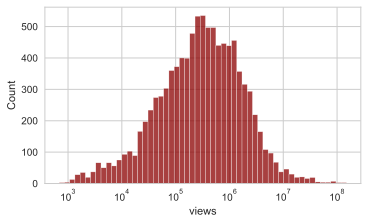

In [88]:
x = df_youtube['views']

plt.figure(figsize=(5,3))
sns.histplot(x, color='darkred', stat='count', edgecolor='w', log_scale=10)
plt.show()

#### Kernel density estimation
[Kernel Density Estimation] (KDE) is a method to estimate the [Probability Density Function] (PDF) of the sample. The approach of this method is to create a [kernel function] $\kappa(x_n)$ for every observation. $\kappa(x_n)$ uses a parameter - bandwidth, denoted $h$ that needs to be optimized. Seaborn uses the Gaussian kernel, which has the equation:

$$\kappa(x) = \frac{1}{h\sqrt{2\pi}} \exp \left(-\frac{(x-x_n)^2}{2h^2}\right) $$

Now we are having $n$ kernels, each one is a normal distribution with the standard deviation $\sigma = h$ and the mean $\mu = x_n$. The KDE is obtained by adding up all kernels, notice that each kernel has the area of 1. The sum is then normalized by dividing $N$, explaining why the KDE has the total area of 1.

$$\text{KDE}(\mathbf{x}) = \frac{1}{N} \sum_{n=1}^{N}{\kappa(x_n)}$$

KDE plots can be drawn with histograms or standalone using the function [`sns.kdeplot()`]

[Kernel Density Estimation]: https://en.wikipedia.org/wiki/Kernel_density_estimation
[Probability Density Function]: https://en.wikipedia.org/wiki/Probability_density_function
[kernel function]: https://en.wikipedia.org/wiki/Kernel_(statistics)
[`sns.kdeplot()`]: https://seaborn.pydata.org/generated/seaborn.kdeplot.html

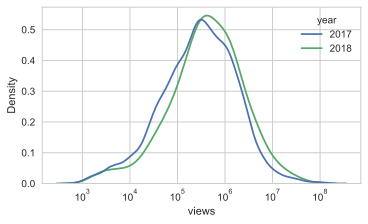

In [87]:
plt.figure(figsize=(5,3))
sns.kdeplot(df_youtube, x='views', hue='year', common_norm=False, log_scale=10)
plt.show()

#### Bivariate histogram
You can place in each of the axes a single variable, then draw a histogram or a KDE to show how it is distributed. For displaying bivariate distribution, there are a couple of choices: scatter plot (with the linear regression line), hexbin plot and heat map. Implemented in Seaborn via [`sns.joinplot()`]

[`sns.joinplot()`]: https://seaborn.pydata.org/generated/seaborn.jointplot.html

In [44]:
df_tip = sns.load_dataset('tips')
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


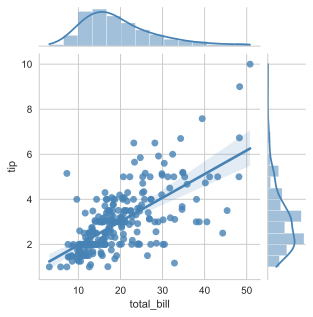

In [85]:
sns.jointplot(data=df_tip, x='total_bill', y='tip', kind='reg', color='steelblue', marginal_kws={'edgecolor':'w'}, height=4.5)
plt.show()

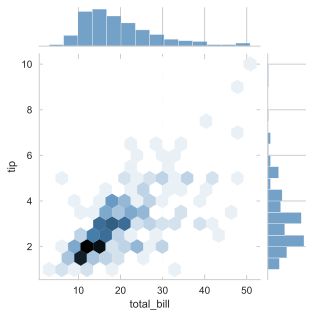

In [86]:
sns.jointplot(data=df_tip, x='total_bill', y='tip', kind='hex', color='steelblue', marginal_kws={'edgecolor':'w'}, height=4.5)
plt.show()

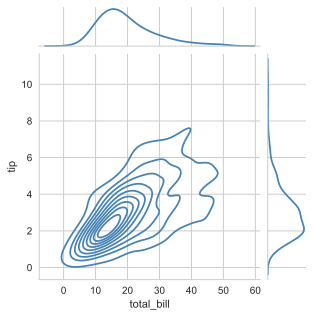

In [84]:
sns.jointplot(data=df_tip, x='total_bill', y='tip', kind='kde', color='steelblue', height=4.5)
plt.show()

### 3.3. Pareto chart

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [12]:
df_youtube = pd.read_csv('../data/youtube_trending.csv')
df_youtube.head()

,video_id,trending_date,channel_title,category_id,publish_time,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled
0,2kyS6SvSYSE,2017-11-14,CaseyNeistat,22,2017-11-13T17:13:01.000Z,748374,57527,2966,15954,False,False
1,1ZAPwfrtAFY,2017-11-14,LastWeekTonight,24,2017-11-13T07:30:00.000Z,2418783,97185,6146,12703,False,False
2,5qpjK5DgCt4,2017-11-14,Rudy Mancuso,23,2017-11-12T19:05:24.000Z,3191434,146033,5339,8181,False,False
3,puqaWrEC7tY,2017-11-14,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,343168,10172,666,2146,False,False
4,d380meD0W0M,2017-11-14,nigahiga,24,2017-11-12T18:01:41.000Z,2095731,132235,1989,17518,False,False


In [24]:
x = df_youtube['views']
x = np.sort(x)
x = x.cumsum() / x.sum()
x[x >= 0.2][0]

0.20008354971750267

### 3.4. Box plot
[Box plots] are less detailed than histograms, but they have the ability to emphasize quartiles and outliers. Implemented in Seaborn via [`sns.boxplot()`].

[Box plots]: https://en.wikipedia.org/wiki/Box_plot
[`sns.boxplot()`]: https://seaborn.pydata.org/generated/seaborn.boxplot.html

In [54]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

#### Basic box plot
Describing a box plot:
- The box visualizes the 3 quartiles: $Q_1$, $Q_2$, $Q_3$ as well as the midrange which includes 50% of the data.
- The lower bound is the smaller of either $Q_1-1.5\cdot\text{IQR}$ or the minimum.
- The upper bound is the greater of either $Q_3+1.5\cdot\text{IQR}$ or the maximum.

:::{note}
Here are useful insights that can be read through box plots:
- Looking for potential outliers: An outlier is a data point that is located outside the whiskers.
- Signs of skewness: You can easily conclude that the data is left-skewed, right-skewed or symmetric by comparing $Q_2-Q_1$ and $Q_3-Q_2$.
- Examining how spread the data is: The longer the midrange and the length of whiskers, the wider the distribution is.
- Comparing categories: If the median of a category lies outside of the box of another one, then there is likely to be a difference between the two categories.
:::

In [55]:
df_tip = sns.load_dataset('tips')
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


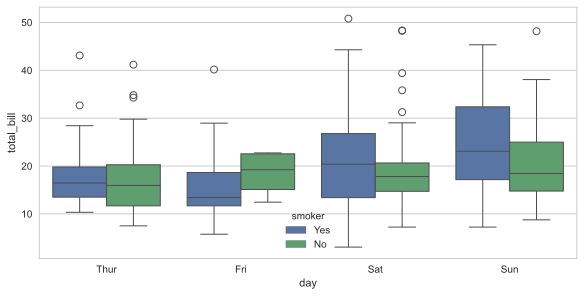

In [83]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_tip, x='day', y='total_bill', hue='smoker')
plt.show()

#### Boxen plot
[Boxen plot] (also known as letter-value plot) is an enhanced version of box plot, implemented in Seaborn as [`sns.boxenplot()`]. Boxen plots have more boxes, allow analyzing larger datasets. This method calculating the number of boxes is defined recursively, starting with the median:

$$d_{i+1} = \frac{1+\lfloor d_i \rfloor}{2}$$

where $d_i$ is the depth of each outer group. $d_1$ represents the depth of the median; $d_2$ represents the depth of the 2 quartiles $Q_1$ and $Q_3$.

[Boxen plot]: http://vita.had.co.nz/papers/letter-value-plot.pdf
[`sns.boxenplot()`]: https://seaborn.pydata.org/generated/seaborn.boxenplot.html

In [51]:
df_tip = sns.load_dataset('tips')
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


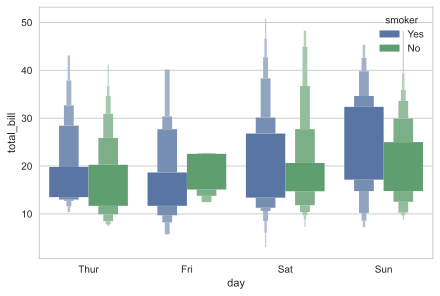

In [82]:
plt.figure(figsize=(6,4))
sns.boxenplot(data=df_tip, x='day', y='total_bill', hue='smoker', k_depth='full', linewidth=0)
plt.show()

## 4. Multivariate visualization

### 4.1. Andrews curves
The [Andrews curve] visualizes clusters of high-dimensional data. Each observation (row) $\mathbf{s}=(x_1, x_2, x_3,\dots)$ is transformed into a curve using [Fourier series] as follows:

$$f_x(t) = \frac{x_1}{\sqrt2} + x_2\sin(t) + x_3\cos(t) + x_4\sin(2t) + x_5\cos(2t) + \dots$$

The function [`andrews_curves()`] in Pandas plots for $t \in [-\pi, \pi]$.

[Andrews curve]: https://en.wikipedia.org/wiki/Andrews_plot
[Fourier series]: https://en.wikipedia.org/wiki/Fourier_series
[`andrews_curves()`]: https://pandas.pydata.org/docs/reference/api/pandas.plotting.andrews_curves.html

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [64]:
df_iris = sns.load_dataset('iris')
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


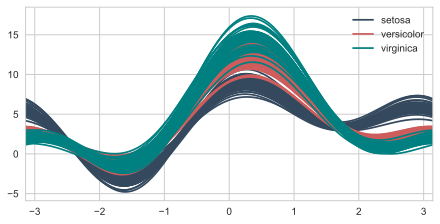

In [81]:
plt.figure(figsize=(6,3))
pd.plotting.andrews_curves(df_iris, 'species', color=['#34495e', 'indianred', 'teal'])
plt.grid()
plt.show()

### 4.2. Parallel coordinates
In [parallel coordinates], each axis represents a single each variable. Implemented in Pandas via [`parallel_coordinates()`].

[parallel coordinates]: https://en.wikipedia.org/wiki/Parallel_coordinates
[`parallel_coordinates()`]: https://pandas.pydata.org/docs/reference/api/pandas.plotting.parallel_coordinates.html

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [57]:
df_iris = sns.load_dataset('iris')
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


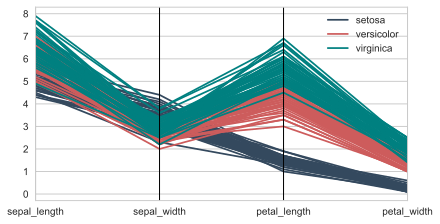

In [80]:
plt.figure(figsize=(6,3))
pd.plotting.parallel_coordinates(df_iris, 'species', color=['#34495e', 'indianred', 'teal'])
plt.grid()
plt.show()

### 4.3. Facet grid
Facet grid is a matrix of plots, where each rows and columns correspond to categories of 2 qualitative variables. The Seaborn's [`sns.catplot()`] function creates a facet grid which is a matrix of plots and is able to display up to 5 variables. The `kind` parameter selects the underlying axes-level visualization to use: `strip` (default) `swarm` `box` `boxen` `violin` `point` `bar` `count`.

[`sns.catplot()`]: https://seaborn.pydata.org/generated/seaborn.catplot.html

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [70]:
df_tip = sns.load_dataset('tips')
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


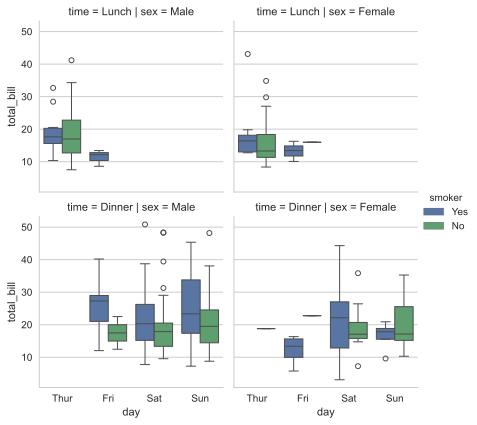

In [79]:
sns.catplot(data=df_tip, x='day', y='total_bill', hue='smoker', col='sex', row='time', kind='box', height=3)
plt.show()

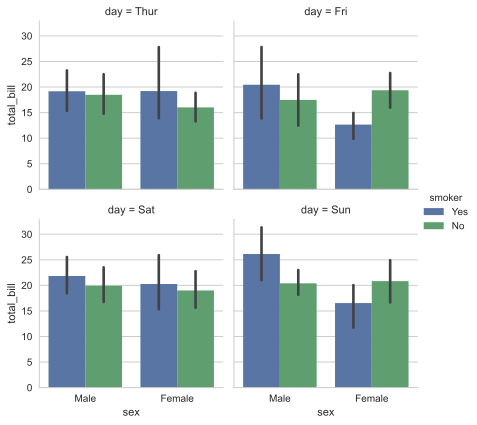

In [78]:
sns.catplot(data=df_tip, x='sex', y='total_bill', hue='smoker', col='day', kind='bar', col_wrap=2, height=3)
plt.show()

### 4.4. Pair grid
Similar to facet grid, pair grid is also a matrix of plots each column and row is assigned to a different quantitative variable, resulting the plots show pairwise relationships in the dataset. Pair grid can be compared with correlation matrix. Implemented in Seaborn via [`sns.pairplot()`].

[`sns.pairplot()`]: https://seaborn.pydata.org/generated/seaborn.pairplot.html

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns

In [64]:
df_iris = sns.load_dataset('iris')
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


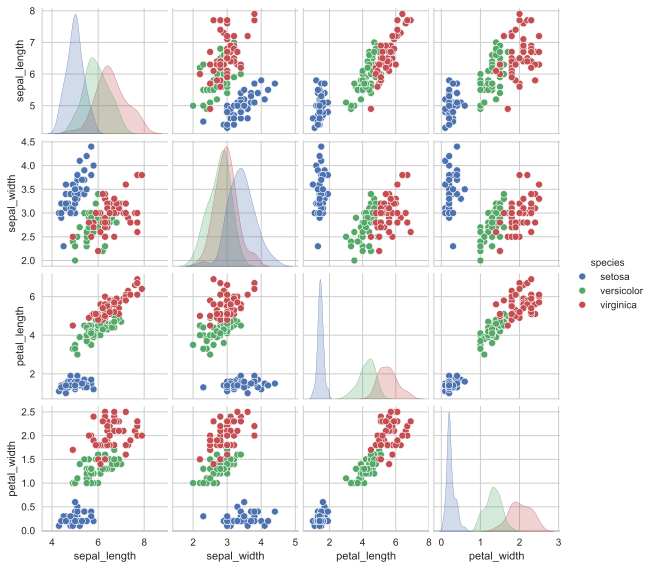

In [77]:
sns.pairplot(data=df_iris, hue='species', height=2)
plt.show()